todo: add docs for inital seelig v1 orth creation

In [16]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
local=True
if local:
    cluster=LocalCluster(
        n_workers=4,
        threads_per_worker=2
    )
    client=Client(cluster)
else:
    cluster=SLURMCluster(
        cores=3,#cores per slurm job
        memory="32G",#memory per slurm job
        processes=3,#dask workers per slurm job,
        job_extra_directives=["-p week", 
            f"--job-name=simclust_worker",
            "--resources \"FIT=1\"",
            f"--time=72:00:00",
            f"--output=worker_%j.out"]
    )
    cluster.scale(jobs=2)
    client = Client(cluster,
            timeout=f"{5*60}s",   # Client <-> scheduler timeout 
            heartbeat_interval="20s"  # Worker heartbeat interval
        )

In [3]:
data_root=Path("/nfs/roberts/project/pi_skr2/shared/tabula_data")
client.dashboard_link

'http://127.0.0.1:8787/status'

In [ ]:
primordial=scm.ortho.load(client,data_root/"seelig","ortho_seelig_v1.5")

In [ ]:
primordial.extract_params(client)

In [4]:
primordial.save(data_root/"seelig","ortho_seelig_v2")

NameError: name 'primordial' is not defined

In [5]:
primordial=scm.ortho.load(client,data_root/"seelig","ortho_seelig_v2")

In [6]:
primordial.compute_model_qc()

In [9]:
by_cre_thetas=[]
for key in primordial.by_cre.model:
    by_cre_thetas.append(primordial.by_cre.model[key].result()["weights"]["theta"].squeeze())
by_cre_thetas=np.array(by_cre_thetas)

by_cell_type_thetas=[]
for key in primordial.by_cell_type.model:
    by_cell_type_thetas.append(primordial.by_cell_type.model[key].result()["weights"]["theta"].squeeze())
by_cell_type_thetas=np.array(by_cell_type_thetas)

<Axes: >

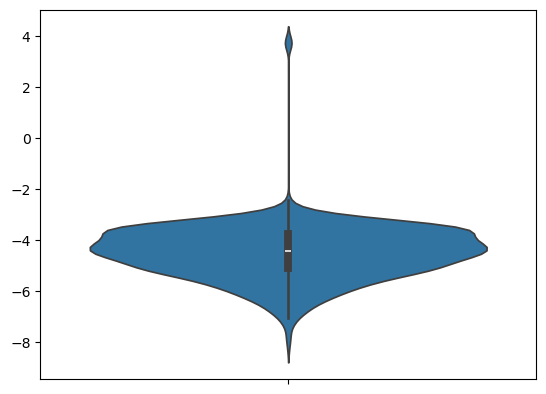

In [10]:
sns.violinplot(by_cre_thetas)

<Axes: >

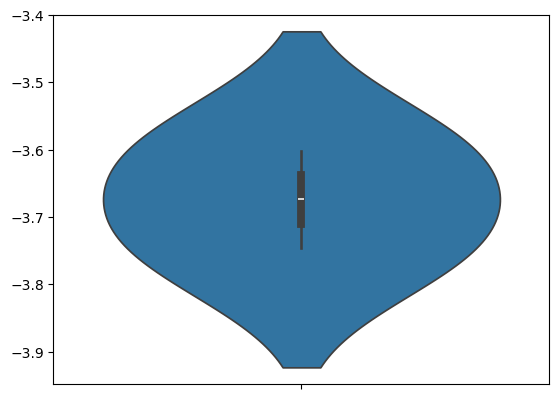

In [11]:
sns.violinplot(by_cell_type_thetas)

In [12]:
np.mean(by_cre_thetas)

-4.492726

In [13]:
np.mean(by_cell_type_thetas)

-3.673921

In [14]:
np.mean(np.concatenate((by_cre_thetas,by_cell_type_thetas)))

-4.4914975

In [17]:
def minimax(QC):
    x=[]
    for level in QC.keys():
        if QC[level]["success"]:
            x.append(QC[level]["dat"])
    x=pd.concat(x)
    print(f"min {min(x['mu'])}, max {max(x['mu'])}")

print("cre")
minimax(primordial.by_cre_qc)
print("ct")
minimax(primordial.by_cell_qc)

cre
min 0.0005816034390591085, max 2.703796625137329
ct
min 0.000558990053832531, max 2.7524495124816895


---
low r AATAGACTGGCGCGCGCGCCTGATGGCGCGCGCGCCTGATCAGGCTATACGTGTTGCGTTGTTGCAGCCCGTGGCGCGCGCGCCTGAACTGGCGCGCGCGCCTGATACCTCTGGGCTGTCACGCGGTGGCGCGCGCGCCTGAAGG
low r ACGCGCTTCGAGATAAGGTTACTTCCTCGTAAGGCCCCGCCCATACGCGTCTTCGAGGACGCGTCTTCTTATCTGTCTTCCCGCGCGCGGAGACGCGTCTTCTTCCTCGTATCGCCCCGCCCATGCGTTCTCTTGAGGACTTCCC
low r AGTCGCTGCGCGATATATCGTCCGCGAGATACGCTTCGCTCCGCCCGCGCTTCCTTCCGCGGAGTCGCGGGTCCTCGCCTCGCGCCTCTTATCGGTGCGCGGCGCTCTTTCGCGAGATATCGCCCCTTTTCGCGCGCTTCCTCGC
low r CCAAAGTCCGCTGGAAAGTACCCAGGGAGCTTGGGGGCTTTGGTCAAACTTTGCACTGCAGGCCTAAAGTCTCTACTGTAATCCTTTCACGTTTATGCCAAGGTCCCTTGTATACAAAACCAAAGTTCAAAGCTCCAGTACACAA
low r CCCCCCCATAACTTCCTATATCGGCGGGGGGGGAGGGGCGGGGCTTCCAGGAAGTGACTCATCGGGGCGGGGCGGGCCCCCCCCCCTATAGGCCCGCCCCCCCCCCCCTTCCCGGAAGCCCCGCCCCCAGAGGATGAGTCATCCG
low r CCCCCCCTATATCTCCCCCCCCGCTCTCACTCATGCGTCTTCCCGCGTTTTTCTTTTTCTATCCGCGTTTTCGCGTATCTTCCTTCCTATACGCTTTCTCATCCGCCCTCTCCTTCTCTCTTCTCCGCGCCCTCCCCCGTTCTCG
low r CCCCCCTTTCCAGGAAGTCGCGGAAGCGCTGAGTCACGATACGCCCCGCCCCCCCGCCCCCCCCCCCCCCCGCCGATG

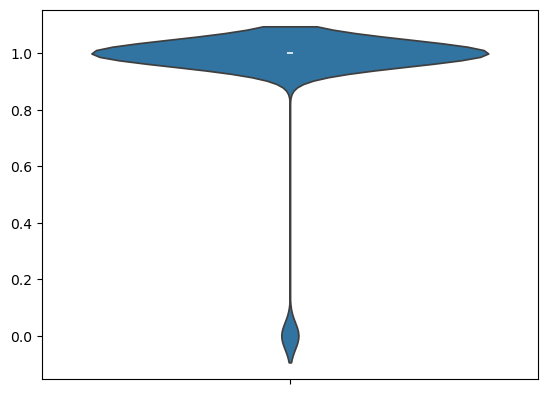

In [18]:
r=[]
for QC in [primordial.by_cre_qc,primordial.by_cell_qc]:
    print("---")
    
    for level in QC.keys():
        if QC[level]["success"]:
            if np.isnan(QC[level]["r_value"]):
                print(f"nan in {level}")
            else:
                if QC[level]["r_value"]<0.8:
                    print(f"low r {level}")
                r.append(QC[level]["r_value"])


sns.violinplot(r)

print(r)

In [ ]:
client.close()
cluster.close()